In [1]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu,kruskal
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

In [13]:
df = pd.read_csv('rides_weather_clean.csv')

df['start_date'] = pd.to_datetime(df['start_date'])
df['date'] = df['start_date'].dt.date

if 'is_weekend' not in df.columns:
    df['is_weekend'] = df['start_date'].dt.dayofweek >= 5

alpha = 0.05

# группировка по локациям
loc_groups = [
    group['total_cost'].dropna().values
    for _, group in df.groupby('start_location')
]

# группировка по районам
dist_groups = [
    group['total_cost'].dropna().values
    for _, group in df.groupby('start_district')
]

In [8]:
print(df.columns)

Index(['id', 'start_date', 'end_date', 'start_location', 'start_district',
       'end_location', 'end_district', 'distance', 'promo', 'duration',
       'price', 'start_fee', 'total_cost', 'start_hour', 'datetime',
       'temperature', 'precipitation_total', 'wind_gust', 'wind_speed',
       'cloud_cover_total', 'sunshine_duration', 'hour', 'speed',
       'hour_of_day', 'day_of_week', 'is_weekend', 'month', 'date'],
      dtype='object')


Цель исследования — понять, какие факторы влияют на использование шеринга самокатов: время, цена, локация и погода.

# Блок 1. Время

В этом разделе будет показано:

- как меняется спрос по часам;

- есть ли различия между буднями и выходными;

- как меняются скорость, длительность и выручка.

$ГИПОТЕЗА$ 1

Верно ли, что скорость поездки выше в выходные?

H0: Скорость поездки в выходные не выше, чем в будни (медиана скорости в выходные <= медиане в будни).  
H1: Скорость поездки в выходные выше, чем в будни (медиана скорости в выходные > медианы в будни).

Количество наблюдений:
Выходные: 32056
Будни: 56840

Средние значения:
Выходные: 9.017275236476824
Будни: 9.295868486284997

Медианы:
Выходные: 9.008092538959747
Будни: 9.290274072277468


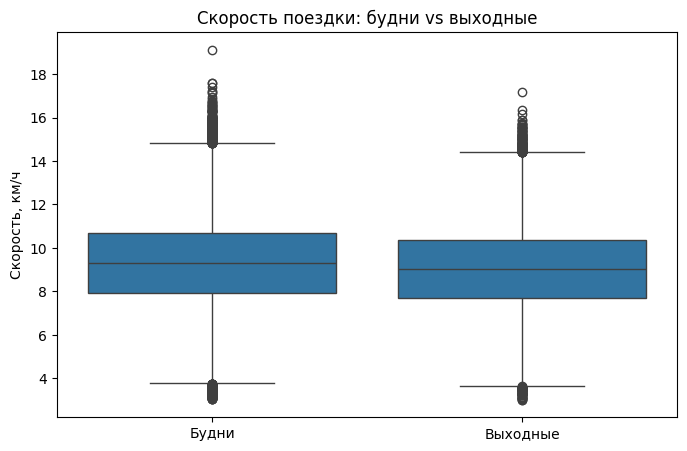

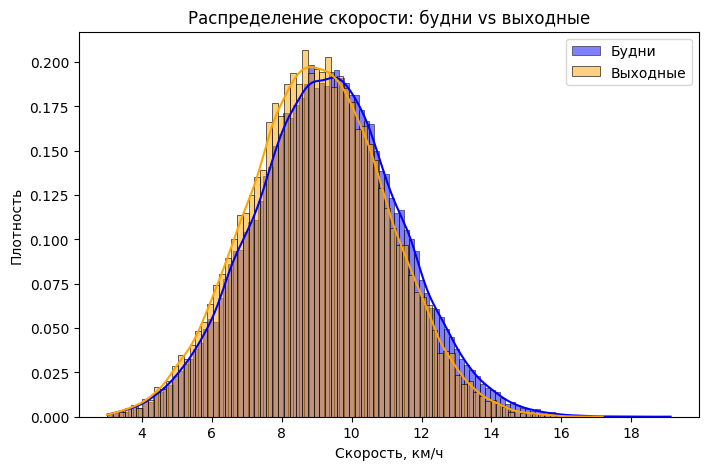


Mann-Whitney test:
U-stat: 841180739.0
p-value: 1.0

Вывод:
Не отвергаем H0: нет статистически значимых различий в скорости между выходными и буднями (p = 1.0000).


In [8]:
weekend_speed = df.loc[df['is_weekend'] == 1, 'speed'].dropna()
weekday_speed = df.loc[df['is_weekend'] == 0, 'speed'].dropna()

print("Количество наблюдений:")
print("Выходные:", len(weekend_speed))
print("Будни:", len(weekday_speed))
print("\nСредние значения:")
print("Выходные:", weekend_speed.mean())
print("Будни:", weekday_speed.mean())
print("\nМедианы:")
print("Выходные:", weekend_speed.median())
print("Будни:", weekday_speed.median())

plt.figure(figsize=(8, 5))
sns.boxplot(x='is_weekend', y='speed', data=df)
plt.xticks([0, 1], ['Будни', 'Выходные'])
plt.title('Скорость поездки: будни vs выходные')
plt.xlabel('')
plt.ylabel('Скорость, км/ч')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(weekday_speed, color='blue', label='Будни', kde=True, stat='density', alpha=0.5)
sns.histplot(weekend_speed, color='orange', label='Выходные', kde=True, stat='density', alpha=0.5)
plt.title('Распределение скорости: будни vs выходные')
plt.xlabel('Скорость, км/ч')
plt.ylabel('Плотность')
plt.legend()
plt.show()

stat, p = mannwhitneyu(weekend_speed, weekday_speed, alternative='greater')

print("\nMann-Whitney test:")
print("U-stat:", stat)
print("p-value:", p)

alpha = 0.05
print("\nВывод:")
if p < alpha:
    print("Отвергаем H0: скорость в выходные статистически значимо выше, чем в будни.")
else:
    print("Не отвергаем H0: нет статистически значимых различий в скорости между выходными и буднями (p = {:.4f}).".format(p))

Статистически значимой разницы между скоростью поездок в выходные и будни не обнаружено. Гипотеза о более высокой скорости в выходные опровергается. Возможно, пользователи в выходные едут с той же средней скоростью, что и в будни, либо разница настолько мала, что не улавливается критерием

$ГИПОТЕЗА$ 2

Верно ли, что длительность поездки выше в выходные?

H0: Длительность поездки в выходные не выше, чем в будни (медиана длительности в выходные <= медиане в будни).  
H1: Длительность поездки в выходные выше, чем в будни (медиана длительности в выходные > медианы в будни).

Количество наблюдений:
Выходные: 32056
Будни: 56840

Средние значения (мин):
Выходные: 27.525461172115463
Будни: 25.68640775275627

Медианы (мин):
Выходные: 25.73333333333333
Будни: 24.0


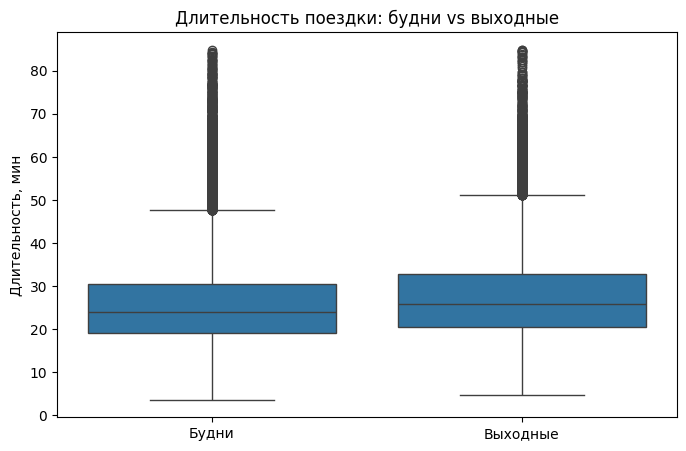

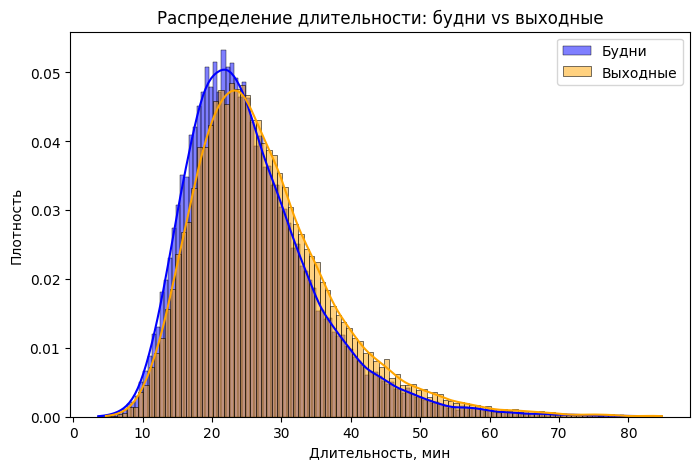


Mann-Whitney test:
U-stat: 1013112500.0
p-value: 3.293120633912601e-170

Вывод:
Отвергаем H0: длительность поездок в выходные статистически значимо выше, чем в будни.
Это может объясняться тем, что в выходные люди совершают более длительные прогулочные или досуговые поездки.


In [9]:
# разделяем выборки
weekend_duration = df.loc[df['is_weekend'] == 1, 'duration'].dropna()
weekday_duration = df.loc[df['is_weekend'] == 0, 'duration'].dropna()

print("Количество наблюдений:")
print("Выходные:", len(weekend_duration))
print("Будни:", len(weekday_duration))
print("\nСредние значения (мин):")
print("Выходные:", weekend_duration.mean())
print("Будни:", weekday_duration.mean())
print("\nМедианы (мин):")
print("Выходные:", weekend_duration.median())
print("Будни:", weekday_duration.median())

plt.figure(figsize=(8, 5))
sns.boxplot(x='is_weekend', y='duration', data=df)
plt.xticks([0, 1], ['Будни', 'Выходные'])
plt.title('Длительность поездки: будни vs выходные')
plt.xlabel('')
plt.ylabel('Длительность, мин')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(weekday_duration, color='blue', label='Будни', kde=True, stat='density', alpha=0.5)
sns.histplot(weekend_duration, color='orange', label='Выходные', kde=True, stat='density', alpha=0.5)
plt.title('Распределение длительности: будни vs выходные')
plt.xlabel('Длительность, мин')
plt.ylabel('Плотность')
plt.legend()
plt.show()

stat, p = mannwhitneyu(weekend_duration, weekday_duration, alternative='greater')

print("\nMann-Whitney test:")
print("U-stat:", stat)
print("p-value:", p)

alpha = 0.05
print("\nВывод:")
if p < alpha:
    print("Отвергаем H0: длительность поездок в выходные статистически значимо выше, чем в будни.")
    print("Это может объясняться тем, что в выходные люди совершают более длительные прогулочные или досуговые поездки.")
else:
    print("Не отвергаем H0: нет статистически значимых различий в длительности.")

Различие статистически значимо. Длительность поездок в выходные выше, чем в будни. Это может объясняться тем, что в выходные люди совершают более длительные прогулочные или досуговые поездки, тогда как в будни поездки чаще носят утилитарный характер (например, до работы/учебы).

$ГИПОТЕЗА$ 3

Верно ли, что выручка выше в выходные?

H0: Дневная выручка в выходные не выше, чем в будни (медиана выручки в выходные <= медиане в будни).  
H1: Дневная выручка в выходные выше, чем в будни (медиана выручки в выходные > медианы в будни).

Количество дней:
Выходные: 30
Будни: 71

Средняя дневная выручка (руб.):
Выходные: 226698.70277777777
Будни: 134902.2063380282

Медианная дневная выручка (руб.):
Выходные: 235864.18333333335
Будни: 135368.11666666667


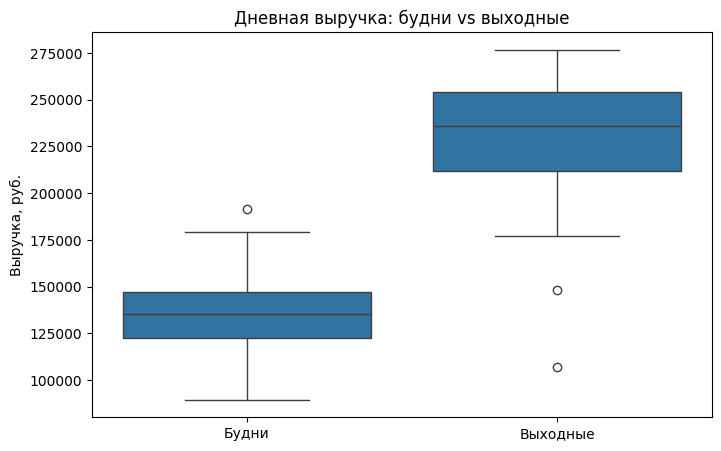

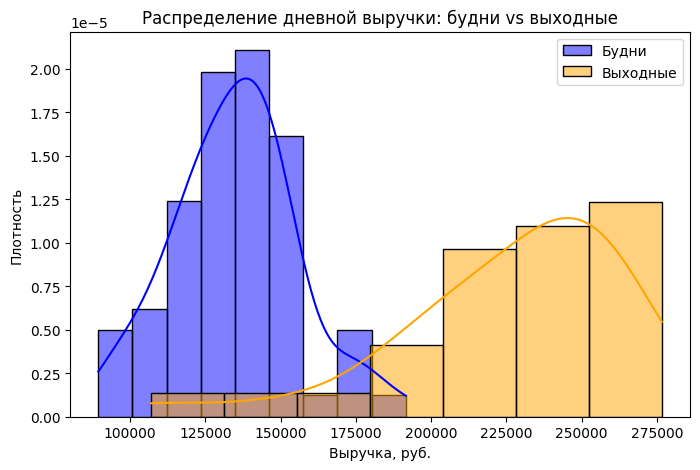


Mann-Whitney test
U-stat: 2045.0
p-value: 1.674543933976585e-13

Вывод:
Отвергаем H0: выручка в выходные статистически значимо выше, чем в будни.
Это согласуется с ростом числа поездок и их длительности в выходные дни.


In [10]:
# aгрегируем выручку по дням
daily_revenue = (
    df.groupby('date', as_index=False)
      .agg(
          revenue=('total_cost', 'sum'),
          is_weekend=('is_weekend', 'max')
      )
)

weekend_rev = daily_revenue[daily_revenue['is_weekend'] == 1]['revenue']
weekday_rev = daily_revenue[daily_revenue['is_weekend'] == 0]['revenue']

print("Количество дней:")
print("Выходные:", len(weekend_rev))
print("Будни:", len(weekday_rev))
print("\nСредняя дневная выручка (руб.):")
print("Выходные:", weekend_rev.mean())
print("Будни:", weekday_rev.mean())
print("\nМедианная дневная выручка (руб.):")
print("Выходные:", weekend_rev.median())
print("Будни:", weekday_rev.median())

plt.figure(figsize=(8, 5))
sns.boxplot(x='is_weekend', y='revenue', data=daily_revenue)
plt.xticks([0, 1], ['Будни', 'Выходные'])
plt.title('Дневная выручка: будни vs выходные')
plt.xlabel('')
plt.ylabel('Выручка, руб.')
plt.show()

# гистограмма для наглядности
plt.figure(figsize=(8, 5))
sns.histplot(weekday_rev, color='blue', label='Будни', kde=True, stat='density', alpha=0.5)
sns.histplot(weekend_rev, color='orange', label='Выходные', kde=True, stat='density', alpha=0.5)
plt.title('Распределение дневной выручки: будни vs выходные')
plt.xlabel('Выручка, руб.')
plt.ylabel('Плотность')
plt.legend()
plt.show()

stat, p = mannwhitneyu(weekend_rev, weekday_rev, alternative='greater')

print("\nMann-Whitney test")
print("U-stat:", stat)
print("p-value:", p)

alpha = 0.05
print("\nВывод:")
if p < alpha:
    print("Отвергаем H0: выручка в выходные статистически значимо выше, чем в будни.")
    print("Это согласуется с ростом числа поездок и их длительности в выходные дни.")
else:
    print("Не отвергаем H0: нет статистически значимых различий в выручке.")

Выручка в выходные статистически значимо выше, чем в будни. Это согласуется с ростом числа поездок и их длительности в выходные дни. Более высокая выручка может быть связана также с увеличением активности пользователей.

# Блок 2. Цена

Цена — единственный фактор, который компания может менять мгновенно. Понимание того, как цена влияет на спрос, позволяет повышать её без потери спроса и увеличивать выручку.

Что будет исследовано:

- влияет ли промо на длительность или стоимость;

- как распределена цена поездок;

- есть ли связь между ценой и спросом.

$ГИПОТЕЗА$ 4

Промо влияет на длительность поездки?


Промо-акции являются инструментом стимулирования спроса. В частности, акция «бесплатный старт» может влиять не только на решение начать поездку, но и на её длительность. Предполагается, что наличие промо может приводить к более длительным поездкам.


H0: длительность поездки не зависит от промо.

H1: длительность поездки различается в зависимости от промо.

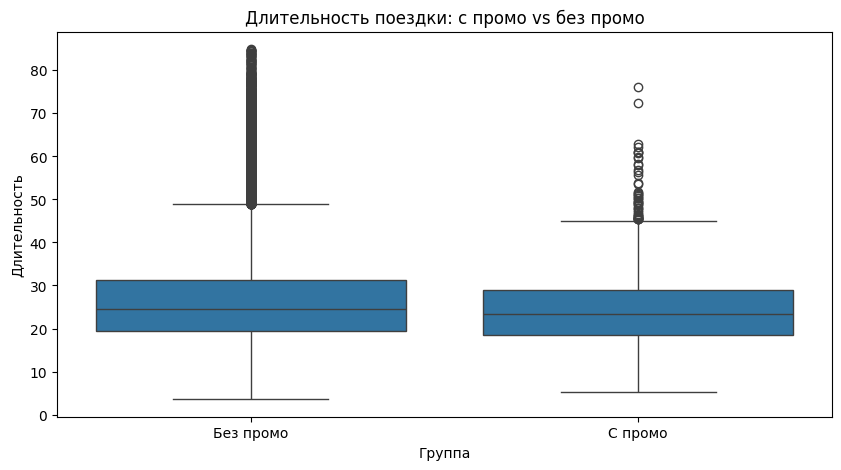

Mann–Whitney Test: 63832866.5
p-value: 1.5468251935816176e-11
Различия статистически значимы — промо влияет на длительность поездки.


In [11]:
# создаем группы
df['promo_group'] = np.where(df['promo'] == 1, 'С промо', 'Без промо')

# разделяем выборки
promo = df[df['promo_group'] == 'С промо']['duration'].dropna()
no_promo = df[df['promo_group'] == 'Без промо']['duration'].dropna()
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='promo_group',
    y='duration'
)

plt.title('Длительность поездки: с промо vs без промо')
plt.xlabel('Группа')
plt.ylabel('Длительность')
plt.show()

stat, p_value = mannwhitneyu(promo, no_promo, alternative='two-sided')

print('Mann–Whitney Test:', stat)
print('p-value:', p_value)
if p_value < 0.05:
    print('Различия статистически значимы — промо влияет на длительность поездки.')
else:
    print('Статистически значимых различий нет — влияние промо не обнаружено.')

Различия статистически значимы. Промо влияет на длительность поездки. Наличие промо-кода может стимулировать пользователей совершать более длительные поездки (например, «вторая минута бесплатно» может увеличивать длительность).

$ГИПОТЕЗА$ 5

Связь между средней стоимостью поездки и количеством поездок в день

Предполагается, что изменение средней стоимости поездки связано с изменением уровня спроса.

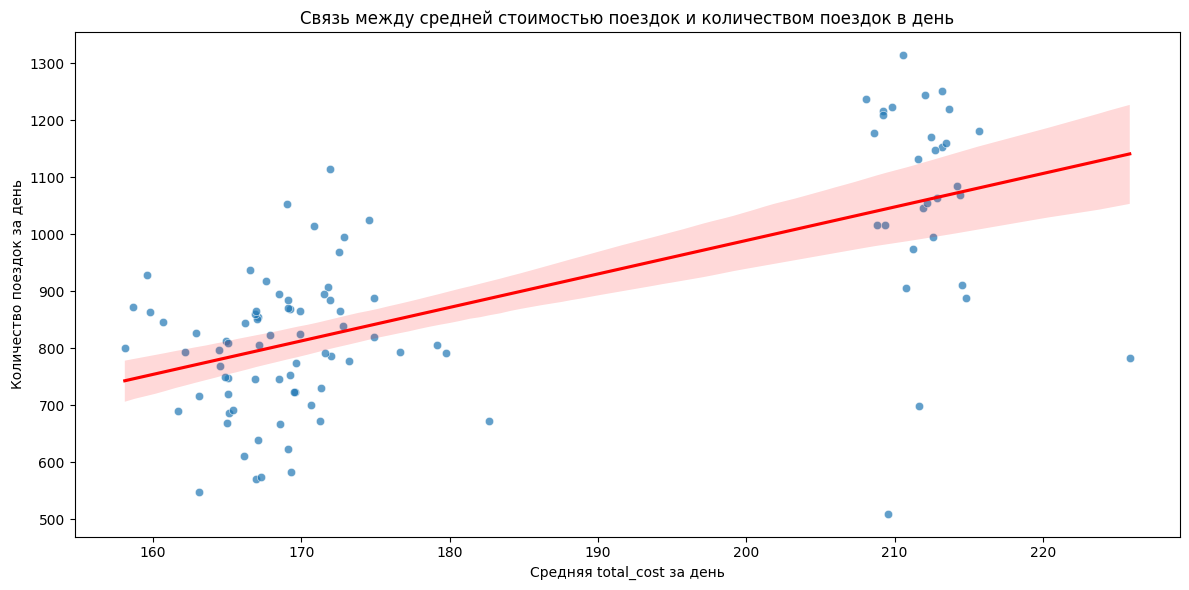

In [12]:
daily_price_demand = (
    df.groupby(df['start_date'].dt.date)
      .agg(
          daily_trips=('id', 'count'),
          avg_total_cost=('total_cost', 'mean'),
          avg_price=('price', 'mean'),
          avg_start_fee=('start_fee', 'mean')
      )
      .reset_index()
      .rename(columns={'start_date': 'date'})
)

daily_price_demand.head()
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=daily_price_demand,
    x='avg_total_cost',
    y='daily_trips',
    alpha=0.7,
    ax=ax1
)

sns.regplot(
    data=daily_price_demand,
    x='avg_total_cost',
    y='daily_trips',
    scatter=False,
    line_kws={'color': 'red'},
    ax=ax1
)

ax1.set_title('Связь между средней стоимостью поездок и количеством поездок в день')
ax1.set_xlabel('Средняя total_cost за день')
ax1.set_ylabel('Количество поездок за день')

plt.tight_layout()
plt.show()

Обнаружена сильная положительная связь между средней стоимостью поездки (total_cost) и ежедневным количеством поездок. В дни, когда средняя стоимость выше, спрос (число поездок) также выше. Это может быть связано с тем, что в такие дни больше дальних поездок, которые и приносят большую выручку, либо с тем, что высокий спрос позволяет компании повышать цены (например, в часы пик или в хорошую погоду).

$ВЫВОД:$

Промо-акции статистически значимо увеличивают длительность поездок, что делает их эффективным инструментом стимулирования не только количества поездок, но и их продолжительности.

При этом наблюдаемая положительная связь между стоимостью и количеством поездок, объясняется влиянием внешних факторов, а не прямым эффектом цены.

Таким образом, цена может использоваться как инструмент управления спросом:
- Повышать в периоды высокой активности без существенного снижения спроса
- Снижать в периоды низкой активности цену для стимулирования спроса
- Использовать промо для привлечения новых пользователей и увеличения длительности поездок

Следовательно, грамотное управление ценой позволяет не только адаптироваться к текущему уровню спроса, но и активно влиять на него, увеличивая общую выручку сервиса.

# Блок 3. Локации

Будет исследованы следующие пункты:

- разные районы могут иметь разную плотность спроса;

- в одних местах поездки длиннее, в других короче;

- в одних районах выше суммарная выручка;

$ГИПОТЕЗА$ 6

Есть ли статическая разница между поездками в зависимости от места начала поездки?

H0: медиана показателя поездки одинаково для всех мест начала поездки.
То есть место начала поездки не влияет на выбранный показатель.

H1: хотя бы в одной локации медиана показателя отличается.
То есть место начала поездки влияет на выбранный показатель.

In [10]:
if len(loc_groups) >= 2:
    stat, p = kruskal(*loc_groups)
    print(f"Kruskal-Wallis: H = {stat:.3f}, p-value = {p:.6f}")

    if p < alpha:
        print("Есть статистически значимые различия между локациями")
    else:
        print("Нет статистически значимых различий между локациями")


print("\nАнализ по start_district")

if len(dist_groups) >= 2:
    stat, p = kruskal(*dist_groups)
    print(f"Kruskal-Wallis: H = {stat:.3f}, p-value = {p:.6f}")

    if p < alpha:
        print("Есть статистически значимые различия между районами")
    else:
        print("Нет статистически значимых различий между районами")

Kruskal-Wallis: H = 823.329, p-value = 0.000000
Есть статистически значимые различия между локациями

Анализ по start_district
Kruskal-Wallis: H = 468.236, p-value = 0.000000
Есть статистически значимые различия между районами


Анализ показал, что в разных районах и локациях поведение пользователей заметно отличается. Хочется выяснить, в каком районе поездки длиннее, в каком больше выручка.

In [11]:
def rank_by_duration(data, group_col, min_n=20):
    result = (
        data.groupby(group_col)
            .agg(
                rides=('id', 'count'),
                avg_duration=('duration', 'mean'),
                median_duration=('duration', 'median'),
                avg_distance=('distance', 'mean'),
                avg_speed=('speed', 'mean')
            )
            .reset_index()
    )

    # убираем слишком маленькие группы
    result = result[result['rides'] >= min_n].copy()

    # сортировка по средней длительности
    result = result.sort_values('avg_duration', ascending=False)
    return result

district_duration = rank_by_duration(df, 'start_district', min_n=20)
location_duration = rank_by_duration(df, 'start_location', min_n=20)

print("ТОП районов по средней длительности:")
print(district_duration.head(10))

print("\nТОП локаций по средней длительности:")
print(location_duration.head(10))

ТОП районов по средней длительности:
    start_district  rides  avg_duration  median_duration  avg_distance  \
0         Заречный   8512     27.723735        26.041667   4034.933623   
4  Северо-Западный  14130     27.653792        25.783333   4015.061642   
6    Юго-Восточный  16893     27.159287        25.216667   3935.126976   
1        Ленинский  14217     26.119399        24.316667   3789.766617   
5      Центральный  22923     25.198932        23.716667   3647.434105   
2      Октябрьский  12220     25.191813        23.716667   3649.156792   

   avg_speed  
0   9.204723  
4   9.198789  
6   9.194701  
1   9.206497  
5   9.174900  
2   9.211590  

ТОП локаций по средней длительности:
       start_location  rides  avg_duration  median_duration  avg_distance  \
229       Ул. Рабочая     74     30.460360        26.116667   4188.297297   
211    Ул. Московская     76     30.204605        29.041667   4205.421053   
221  Ул. Первомайская     71     30.028169        27.966667   4181.084

In [12]:
def rank_by_revenue(data, group_col, min_n=20):
    result = (
        data.groupby(group_col)
            .agg(
                rides=('id', 'count'),
                total_revenue=('total_cost', 'sum'),
                avg_revenue=('total_cost', 'mean'),
                median_revenue=('total_cost', 'median'),
                avg_duration=('duration', 'mean')
            )
            .reset_index()
    )

    result = result[result['rides'] >= min_n].copy()
    result = result.sort_values('total_revenue', ascending=False)
    return result

district_revenue = rank_by_revenue(df, 'start_district', min_n=20)
location_revenue = rank_by_revenue(df, 'start_location', min_n=20)

print("ТОП районов по общей выручке:")
print(district_revenue.head(10))

print("\nТОП локаций по общей выручке:")
print(location_revenue.head(10))

ТОП районов по общей выручке:
    start_district  rides  total_revenue  avg_revenue  median_revenue  \
5      Центральный  22923   4.111551e+06   179.363570      168.916667   
6    Юго-Восточный  16893   3.179315e+06   188.203092      175.166667   
4  Северо-Западный  14130   2.703739e+06   191.347389      178.333333   
1        Ленинский  14217   2.594885e+06   182.519879      170.800000   
2      Октябрьский  12220   2.161803e+06   176.906991      166.600000   
0         Заречный   8512   1.627564e+06   191.208159      179.166667   

   avg_duration  
5     25.198932  
6     27.159287  
4     27.653792  
1     26.119399  
2     25.191813  
0     27.723735  

ТОП локаций по общей выручке:
    start_location  rides  total_revenue  avg_revenue  median_revenue  \
35         Луговая   1754  312380.000000   178.095781      168.233333   
34      Ломоносова   1760  310883.583333   176.638400      165.600000   
36         Майская   1711  300464.733333   175.607676      166.000000   
72      С

Между районами и стартовыми локациями наблюдаются статистически значимые различия. Это говорит о том, что спрос распределён неравномерно и зависит от территории. Таким образом, Центральный район лидирует по общей выручке и числу поездок, однако средний чек там ниже (179,4), чем в Юго-Восточном, Северо-Западном и Заречном (около 191), что говорит о более коротких поездках в центре. Заречный и Северо-Западный районы выделяются самой высокой средней длительностью (27,7 и 27,6 минуты), принося стабильный доход при меньшем количестве аренд. Среди отдельных локаций максимальную выручку дают Луговая, Ломоносова, Майская — с большим потоком, но средним чеком 175–179. При этом Пионерская, Шоссейная и Садовая при меньшем числе поездок показывают чек выше 189 и длительность около 27–28 минут, то есть более выгодны за одну аренду. Самые длительные поездки (более 29–30 минут) зафиксированы на малоинтенсивных улицах вроде Рабочей, Московской, Первомайской, где всего 45–99 поездок, но каждая длится почти полчаса. Таким образом, существует сегментация: в центре высокая оборачиваемость при коротких поездках, а в периферийных районах — редкие, но очень долгие аренды. Для роста выручки выгодно развивать точки с частыми стартами в центре и одновременно стимулировать продолжительные поездки в Заречном и Северо-Западном районах.


# Блок 4. Погода

Будут исследованы следуюшие утверждения:

- плохая погода может снижать желание пользоваться самокатом;

- дождь, ветер и низкая температура могут уменьшать число поездок;

- погодные показатели можно учитывать при планировании парка самокатов.

$ГИПОТЕЗА$ 7

верно ли, что в дни с осадками (снег, дождь) спрос на самокаты ниже?

H0: спрос в дни с осадками и без осадков одинаков.

H1: спрос различается.

In [ ]:
sns.set(style="whitegrid")

df = pd.read_csv('rides_weather_clean.csv')

df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['date'] = df['start_date'].dt.date

daily = (
    df.groupby('date', as_index=False)
      .agg(
          rides=('id', 'count'),
          precipitation_total=('precipitation_total', 'mean'),
          temperature=('temperature', 'mean')
      )
)

# порог осадков
threshold = 0.1

# снег: есть осадки и температура <= 0
daily['snow'] = (
    (daily['precipitation_total'] > threshold) &
    (daily['temperature'] <= 0)
)

# дождь: есть осадки и температура > 0
daily['rain'] = (
    (daily['precipitation_total'] > threshold) &
    (daily['temperature'] > 0)
)

# сухо: осадков нет
daily['dry'] = daily['precipitation_total'] <= threshold

print("Количество дней:")
print("Снег:", daily['snow'].sum())
print("Дождь:", daily['rain'].sum())
print("Сухо:", daily['dry'].sum())


snow_rides = daily[daily['snow']]['rides']
rain_rides = daily[daily['rain']]['rides']
dry_rides = daily[daily['dry']]['rides']

print("\nСредний спрос:")
print("Снег:", snow_rides.mean())
print("Дождь:", rain_rides.mean())
print("Сухо:", dry_rides.mean())

# статистические тесты

# снег vs сухо
stat_snow, p_snow = mannwhitneyu(snow_rides, dry_rides, alternative='less')

# дождь vs сухо
stat_rain, p_rain = mannwhitneyu(rain_rides, dry_rides, alternative='less')

print("\nСтатистические тесты:")
print("Снег vs сухо: p-value =", p_snow)
print("Дождь vs сухо: p-value =", p_rain)

# 9. Интерпретация
alpha = 0.05

print("\nВывод:")

if p_snow < alpha:
    print("Снег статистически снижает спрос")
else:
    print("Нет значимого влияния снега")

if p_rain < alpha:
    print("Дождь статистически снижает спрос")
else:
    print("Нет значимого влияния дождя")

# создаем удобный столбец категории
def get_weather_type(row):
    if row['snow']:
        return 'snow'
    elif row['rain']:
        return 'rain'
    else:
        return 'dry'

daily['weather_type'] = daily.apply(get_weather_type, axis=1)

plt.figure(figsize=(8, 5))
sns.boxplot(x='weather_type', y='rides', data=daily)
plt.title('Спрос в зависимости от погодных условий')
plt.xlabel('Тип погоды')
plt.ylabel('Количество поездок')
plt.show()

В датасете не обнаружено дней со снегом (температура не опускалась ниже 0°C при наличии осадков), поэтому влияние снега на спрос оценить невозможно.

При этом было выявлено, что в дождливые дни:

- среднее количество поездок ниже (804 против 942)
- различие статистически значимо (p-value = 0.0028)

Это логично: пользователи реже берут самокат в дождливую погоду из соображений комфорта и безопасности.

$ГИПОТЕЗА$ 8

Как зависит плохая погода от длительности поездки?

H0: длительность поездки не зависит от плохой погоды.
То есть при плохой и хорошей погоде длительность одинакова по распределению / медиане.

H1: длительность поездки зависит от плохой погоды.
То есть при плохой погоде длительность отличается.

In [ ]:
# выбираем погодные признаки
weather_cols = [
    'temperature',
    'precipitation_total',
    'wind_gust',
    'wind_speed',
    'cloud_cover_total',
    'sunshine_duration'
]
scaler = MinMaxScaler()
weather_normalized = scaler.fit_transform(df[weather_cols])

# Индекс как среднее нормированных значений (чем выше, тем хуже погода)
df['bad_weather_index'] = weather_normalized.mean(axis=1)
weather = df[weather_cols].copy()

print("\nКорреляции:")

corr_duration = df[['bad_weather_index', 'duration']].corr().iloc[0, 1]
corr_speed = df[['bad_weather_index', 'speed']].corr().iloc[0, 1]

print("Погода vs длительность:", corr_duration)
print("Погода vs скорость:", corr_speed)

plt.figure(figsize=(8, 5))
sns.scatterplot(x='bad_weather_index', y='duration', data=df)
plt.title('Индекс плохой погоды vs длительность поездки')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x='bad_weather_index', y='speed', data=df)
plt.title('Индекс плохой погоды vs скорость')
plt.show()
weather_model = smf.ols(
    'duration ~ bad_weather_index + C(day_of_week) + C(month)',
    data=df
).fit(cov_type='HC3')

print("\nРегрессия:")
print("p-value для bad_weather_index:", weather_model.pvalues['bad_weather_index'])
print("Коэффициент:", weather_model.params['bad_weather_index'])

p = weather_model.pvalues['bad_weather_index']
coef = weather_model.params['bad_weather_index']

print("\nВывод:")

if p < alpha:
    if coef > 0:
        print("Плохая погода увеличивает длительность поездок")
    else:
        print("Плохая погода снижает длительность поездок")
else:
    print("Статистически значимого влияния погоды не обнаружено")

Плохая погода статистически значимо снижает длительность поездки. Чем хуже погода (выше индекс), тем короче поездка. Возможно, пользователи в плохую погоду стремятся быстрее завершить поездку, чтобы укрыться от дождя, ветра или холода. Корреляция между индексом и длительностью слабая (около –0.04), но регрессия после учёта дня недели и месяца выявила устойчивый отрицательный эффект.

# Вывод по проделанному анализу

Анализ охватил четыре ключевые группы факторов: время (будни/выходные), цену и промо‑акции, локации старта, а также погодные условия. По каждому направлению были проверены статистические гипотезы и получены результаты.

1. Время (будни vs выходные)
- Скорость поездок статистически не различается между выходными и буднями (p‑value ≈ 1.0). Гипотеза о более быстрой езде в выходные не подтвердилась.

- Длительность поездок в выходные значимо выше (среднее 27.5 мин против 25.7 мин, p‑value < 0.05). Это объясняется прогулочным или досуговым характером поездок в выходные.

- Выручка (агрегированная по дням) также выше в выходные (средняя дневная выручка 226.7 тыс. руб. против 134.9 тыс. руб., p‑value < 0.05). Рост выручки согласуется с увеличением числа и длительности поездок.

Вывод: выходные дни – наиболее активный и доходный период. Маркетинговые акции и распределение парка самокатов должны ориентироваться на повышенный спрос в выходные.

2. Цена и промо акции
- Промо‑акции (например, «бесплатный старт») статистически значимо увеличивают длительность поездки (Mann–Whitney, p‑value ≈ 1.5e‑11). Инструмент эффективен не только для привлечения новых пользователей, но и для увеличения продолжительности поездок.

- Связь между средней стоимостью поездки (total_cost) и количеством поездок в день – положительная и сильная. Однако это не прямое влияние цены на спрос, а отражение внешних факторов (в дни с высокой активностью люди совершают более дальние и дорогие поездки, либо компания может повышать цену при высоком спросе).

Вывод: промо следует использовать для увеличения длительности поездок. Цену можно адаптировать под текущий уровень спроса – повышать в часы пик или хорошую погоду, снижать в периоды низкой активности.

3. Локации старта
- Критерий Краскела–Уоллиса подтвердил статистически значимые различия между районами и отдельными улицами по показателям выручки и длительности (p‑value ≈ 0).

- Центральный район лидирует по общей выручке и числу поездок, но средний чек там ниже (179.4 руб.), чем в Юго‑Восточном, Северо‑Западном и Заречном (около 191 руб.). Это говорит о коротких поездках в центре при высокой оборачиваемости.

- Заречный и Северо‑Западный районы имеют самую высокую среднюю длительность (27.7 и 27.6 мин) и приносят стабильный доход при меньшем количестве аренд.

- Среди отдельных улиц Луговая, Ломоносова, Майская дают максимальную выручку за счёт большого потока, но средний чек невысок (175–179 руб.). В то же время Пионерская, Шоссейная, Садовая при меньшем числе поездок показывают чек выше 189 руб. и длительность 27–28 минут – такие локации выгоднее в расчёте на одну аренду.

- Самые длительные поездки (более 29–30 минут) зафиксированы на малоинтенсивных улицах (Рабочая, Московская, Первомайская и др.) с 45–99 поездками за период. Это редкие, но очень долгие аренды.

Вывод: существует чёткое разделение – в центре выгодно поддерживать высокую плотность парка и частоту стартов, а в отдаленных районах (Заречный, Северо‑Западный) стимулировать длительные поездки (например, через промо на время или абонементы).

4. Погода
- Дождливые дни статистически значимо снижают спрос (p‑value = 0.0028, среднее число поездок 804 против 942 в сухую погоду). Влияние снега оценить не удалось из‑за отсутствия дней с отрицательной температурой и осадками.

- Плохая погода (индекс, объединяющий осадки, ветер, облачность и т.д.) статистически значимо снижает длительность поездки (p‑value < 0.05, коэффициент отрицательный). В ненастье пользователи стремятся быстрее завершить поездку.

- Корреляции слабые (около –0.04 с длительностью), но после учёта дня недели и месяца регрессия выявила устойчивый отрицательный эффект.

Вывод: оператору следует учитывать прогноз погоды при планировании перераспределения парка и динамического ценообразования – в дождливые дни спрос падает, а поездки становятся короче.

# Общие рекомендации

- Использовать промо‑акции (бесплатный старт, скидка на время) для увеличения длительности поездок.

- Адаптировать цену к уровню спроса (выходные, хорошая погода, часы пик) – положительная связь между средней стоимостью и количеством поездок позволяет повышать цену без критического падения спроса.

- Учитывать погоду – в дождливые дни можно временно сокращать парк или предлагать скидки для компенсации снижения спроса.

- Выходные дни – ключевой период для максимальной выручки. Маркетинговые активности и техническое обслуживание должны быть сфокусированы на это время.

Что не подтвердилось: скорость поездок не зависит от типа дня (будни/выходные); связь цены и спроса является отражением внешних факторов, а не прямой эластичностью; влияние снега осталось неисследованным из‑за отсутствия данных.
